# Pizza Sales Analysis
> **Objective:** identify which products, order types, and periods generate the restaurant's revenue, and uncover sales growth opportunities that can support assortment management, promotion, and operational planning.

Import required libraries

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

Connect to the database, load the tables, and create the `pizza_table` SQL view containing the main information in a single table.

In [165]:
engine = create_engine('DB_Connection_info')
sns.set_theme(style='darkgrid')

Retrieve the data from the database and convert hours and months to integer data types, since the dataset covers a single year and does not include the day of the month.

In [166]:
pizza = pd.read_sql('pizza_table', engine)
pizza['month'] = pizza['month'].astype(int)
pizza['hour'] = pizza['hour'].astype(int)
pd.options.display.float_format = '{:.2f}'.format

pizza.head()


,order_id,month,hour,quantity,pizza_id,name,category,size,price,revenue
0,1,1,11,1,hawaiian_m,The Hawaiian Pizza,Classic,M,13.25,13.25
1,2,1,11,1,classic_dlx_m,The Classic Deluxe Pizza,Classic,M,16.00,16.00
2,2,1,11,1,five_cheese_l,The Five Cheese Pizza,Veggie,L,18.50,18.50
3,2,1,11,1,ital_supr_l,The Italian Supreme Pizza,Supreme,L,20.75,20.75
4,2,1,11,1,mexicana_m,The Mexicana Pizza,Veggie,M,16.00,16.00


#### Key Metrics

In [167]:
print(f"Number of orders: {pizza['order_id'].nunique()}")
print(f"Number of pizzas sold: {pizza['quantity'].sum()}")
print(f"Revenue: {pizza['revenue'].sum()}")
order_revenue = pizza.groupby('order_id')['revenue'].sum().reset_index()
print(f"Average check: {order_revenue['revenue'].mean()}")

Количество заказов: 21350
Проданных пицц: 49574
Доход: 817860.0499999999
Средний чек: 38.30726229508197


# Question 1: Which products drive the restaurant's sales?
> We start by analyzing individual pizza types. This will help identify the products that generate the largest share of sales and understand how strongly revenue depends on a small number of the most popular items.

In [168]:
pizza_items = (
    pizza.groupby('name').agg(
        quantity=('quantity', 'sum'),
        revenue=('revenue', 'sum'),
        price=('price', 'median')
    )
)
pizza_items['revenue_share'] = pizza_items['revenue'] / pizza_items['revenue'].sum() * 100
pizza_items.sort_values('quantity', ascending=False)

,quantity,revenue,price,revenue_share
name,,,,
The Classic Deluxe Pizza,2453,38180.50,16.00,4.67
The Barbecue Chicken Pizza,2432,42768.00,16.75,5.23
The Hawaiian Pizza,2422,32273.25,13.25,3.95
The Pepperoni Pizza,2418,30161.75,12.50,3.69
The Thai Chicken Pizza,2371,43434.25,20.75,5.31
The California Chicken Pizza,2370,41409.50,16.75,5.06
The Sicilian Pizza,1938,30940.50,16.25,3.78
The Spicy Italian Pizza,1924,34831.25,20.75,4.26
The Southwest Chicken Pizza,1917,34705.75,20.75,4.24


### Determine what share of total revenue is generated by the top 10 pizzas

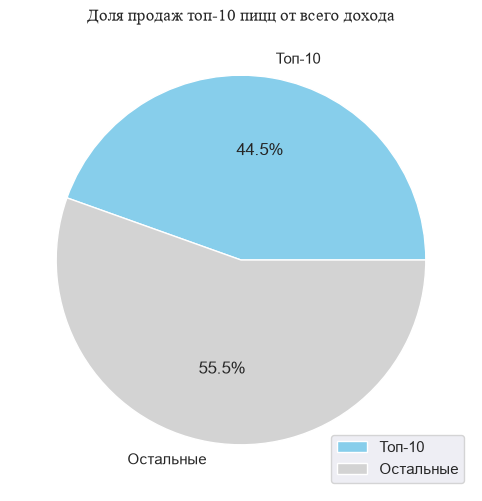

In [169]:
total_revenue = pizza['revenue'].sum()

top = pizza.groupby('name')['revenue'].sum().reset_index().sort_values('revenue', ascending=False)
top_frac = top.iloc[:10]['revenue'].sum()

fraction_top = (top_frac / total_revenue) * 100

plt.figure(figsize=(12, 6), dpi=100)
plt.pie(
    [top_frac, total_revenue - top_frac],
    labels=['Топ-10', 'Остальные'],
    autopct='%1.1f%%',
    colors=['skyblue', 'lightgrey']
)
plt.title(label='Доля продаж топ-10 пицц от всего дохода', font='Times New Roman')
plt.legend(loc='lower right')

The top 10 products account for _44.5%_ of revenue. Therefore, financial performance is significantly concentrated among a limited number of products. These items require particular attention in terms of availability and promotion.

# Question 2: How do sales change throughout the year?
1. monthly revenue
2. monthly number of orders
3. average check
4. average number of pizzas per order
5. which months/periods perform best and worst

#### 1. First, calculate monthly revenue

In [170]:
month_revenue = pizza.groupby('month')['revenue'].sum().reset_index()
month_revenue

,month,revenue
0,1,69793.30
1,2,65159.60
2,3,70397.10
3,4,68736.80
4,5,71402.75
5,6,68230.20
6,7,72557.90
7,8,68278.25
8,9,64180.05
9,10,64027.60


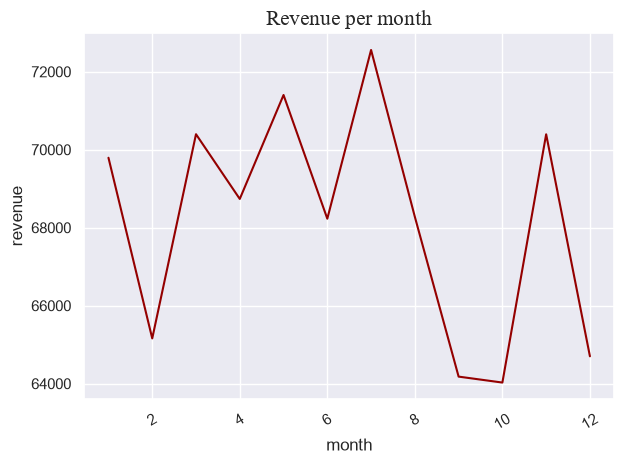

In [171]:
sns.lineplot(data=month_revenue, x='month', y='revenue', color='#940000')
plt.xticks(rotation=30)
plt.title(label='Revenue per month', font='Times New Roman', fontsize=15)
plt.tight_layout()

In [172]:
max_rev = pizza.groupby('month')['revenue'].sum().max()
min_rev = pizza.groupby('month')['revenue'].sum().min()
diff = (max_rev / min_rev - 1) * 100
print(f'Difference: {diff:.2f}%')

Разница: 13.32%


#### 2. Calculate how the number of orders changed by month

<Axes: xlabel='month', ylabel='order_id'>

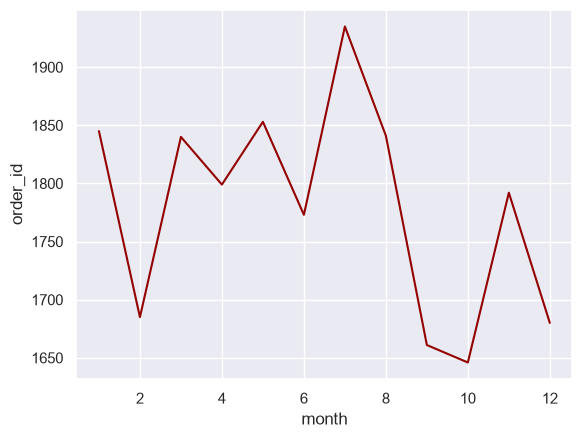

In [173]:
month_count = pizza.groupby('month')['order_id'].nunique().reset_index()

sns.lineplot(data=month_count, x='month', y='order_id', color='#940000')

In [1]:
monthly_avg_check = (
    pizza.groupby('month')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique')
    )
).reset_index()
monthly_avg_check['avg_check'] = monthly_avg_check['revenue'] / monthly_avg_check['orders']

sns.lineplot(
    data=monthly_avg_check,
    x='month',
    y='avg_check'
)
plt.title(label='Average check per month')

NameError: name 'pizza' is not defined

July recorded 1,935 orders, the highest number during the year. At the same time, the average check was not at its maximum, indicating that July's high revenue was primarily driven by a larger number of orders.

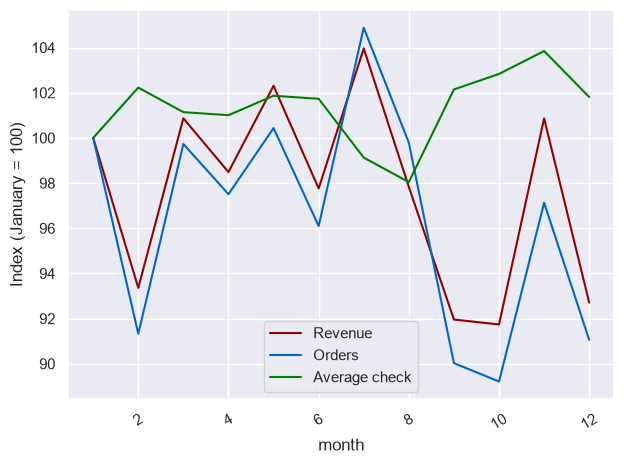

In [175]:
sns.lineplot(
    data=month_revenue.assign(revenue=month_revenue['revenue'] / month_revenue['revenue'].iloc[0] * 100),
    x='month',
    y='revenue',
    color='#940000',
    label='Revenue'
)

sns.lineplot(
    data=month_count.assign(order_id=month_count['order_id'] / month_count['order_id'].iloc[0] * 100),
    x='month',
    y='order_id',
    color='#0066CC',
    label='Orders'
)

sns.lineplot(
    data=monthly_avg_check.assign(avg_check=monthly_avg_check['avg_check'] / monthly_avg_check['avg_check'].iloc[0] * 100),
    x='month',
    y='avg_check',
    color='#008000',
    label='Average check'
)

plt.ylabel('Index (January = 100)')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

Revenue changes are driven primarily by the number of orders, while the average check varies much less.
***

# Question 3: How do sales change by time of day?

In [176]:
orders = pd.read_sql('order_summary', engine)

hour_analysis = (
    orders.groupby('hour')
    .agg(
        orders=('order_id', 'count'),
        revenue=('total', 'sum'),
        avg_check=('total', 'mean')
    )
    .reset_index()
)
hour_analysis

,hour,orders,revenue,avg_check
0,9.00,1,83.00,83.00
1,10.00,8,303.65,37.96
2,11.00,1231,44935.80,36.50
3,12.00,2520,111877.90,44.40
4,13.00,2455,106065.70,43.20
5,14.00,1472,59201.40,40.22
6,15.00,1468,52992.30,36.10
7,16.00,1920,70055.40,36.49
8,17.00,2336,86237.45,36.92
9,18.00,2399,89296.85,37.22


Text(0, 0.5, 'Выручка')

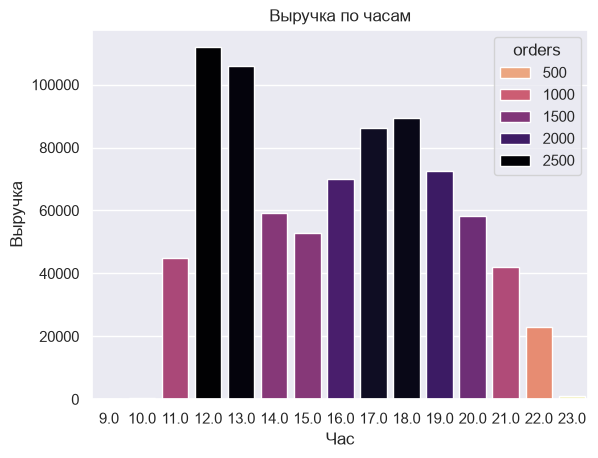

In [177]:
sns.barplot(data=hour_analysis, x='hour', y='revenue', hue='orders', palette='magma_r')
plt.title('Выручка по часам')
plt.xlabel('Час')
plt.ylabel('Выручка')

Most revenue is generated during the daytime and evening hours, particularly between _16:00_ and _20:00_. The highest revenue is observed around _12:00–13:00_ and _17:00–18:00_. After _20:00_, revenue gradually declines and becomes significantly lower by _22:00_.

# Question 4: How does the average check change?

A separate SQL view was created to analyze the average check, with one row representing each order.

In [178]:
orders['month'] = orders['month'].astype(int)
orders['hour'] = orders['hour'].astype(int)
orders['total_pizzas'] = orders['total_pizzas'].astype(int)
orders = orders.rename(columns={'total_pizzas': 'quantity'})
orders = orders.drop(columns='pizza_types')
orders.head()

,order_id,month,hour,quantity,total
0,1,1,11,1,13.25
1,2,1,11,5,92.00
2,3,1,12,2,37.25
3,4,1,12,1,16.50
4,5,1,12,1,16.50


In [179]:
print(f"Median number of pizzas per order: {orders['quantity'].median()}")

Медианное количество пицц в заказе: 2.0


In [180]:
avg_pizzas_per_order = orders.groupby('month')['quantity'].mean().reset_index()
avg_pizzas_per_order

,month,quantity
0,1,2.29
1,2,2.35
2,3,2.32
3,4,2.31
4,5,2.34
5,6,2.32
6,7,2.27
7,8,2.26
8,9,2.34
9,10,2.36


- How does the average check change depending on the number of pizzas in an order?

<Axes: xlabel='quantity', ylabel='total'>

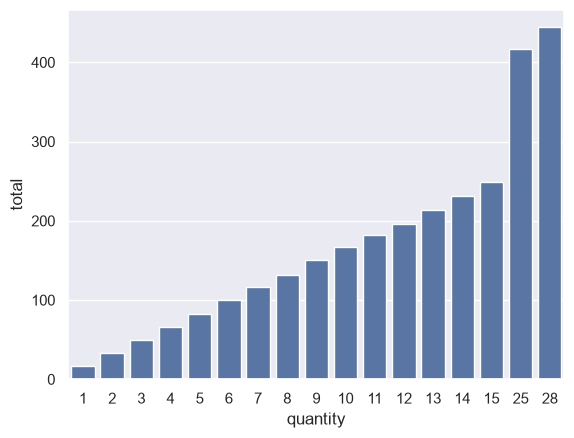

In [181]:
sns.barplot(
    data=orders,
    x='quantity',
    y='total',
    errorbar=None
)

The average check increases as the number of pizzas in an order increases.

# Question 5: Pizza Category Analysis

In [182]:
category = (
    pizza.groupby('category').agg(
        revenue=('revenue', 'sum'),
        quantity=('quantity', 'sum')
    )
).reset_index()
category['revenue_share'] = category['revenue'] / category['revenue'].sum() * 100
category

,category,revenue,quantity,revenue_share
0,Chicken,195919.50,11050,23.96
1,Classic,220053.10,14888,26.91
2,Supreme,208197.00,11987,25.46
3,Veggie,193690.45,11649,23.68


<Axes: xlabel='category', ylabel='revenue'>

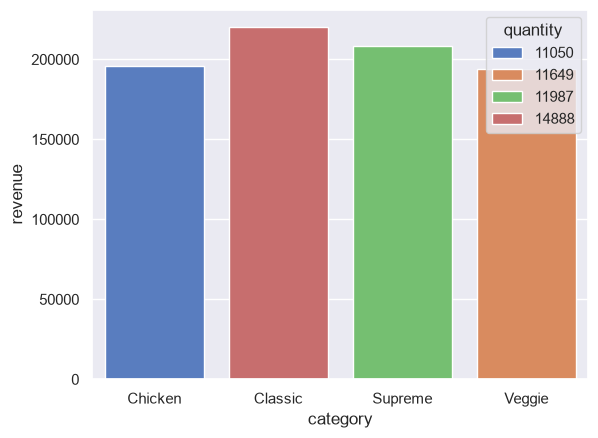

In [183]:
sns.barplot(data=category, x='category', y='revenue', hue='quantity', palette='muted')


The _'Classic'_ category accounts for 26.91% of total revenue and is the largest category by sales volume.

In [184]:
size = pizza.groupby('size').agg(revenue=('revenue', 'sum'), quantity=('quantity', 'sum')).reset_index()
size['revenue_share'] = size['revenue'] / size['revenue'].sum() * 100
size

,size,revenue,quantity,revenue_share
0,L,375318.70,18956,45.89
1,M,249382.25,15635,30.49
2,S,178076.50,14403,21.77
3,XL,14076.00,552,1.72
4,XXL,1006.60,28,0.12


<Axes: xlabel='size', ylabel='revenue'>

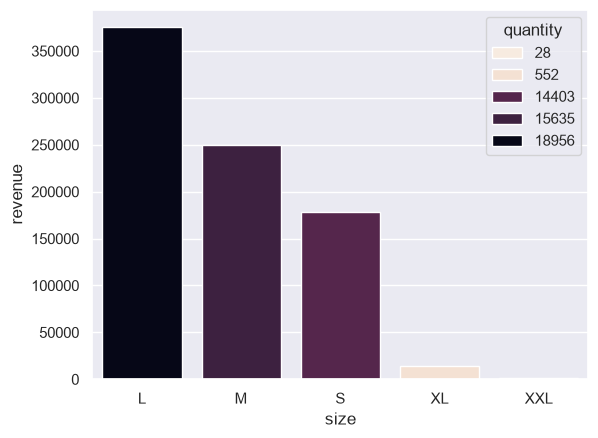

In [185]:
sns.barplot(data=size, x='size', y='revenue', hue='quantity', palette='rocket_r')

The L size accounts for 45.89% of total revenue and is the main source of revenue among pizza sizes. XXL demonstrates extremely low sales volume compared with other sizes, with only 28 units sold. This item requires an assessment of its economic viability and may be a candidate for assortment review.

# Summary
1. The top 10 pizzas account for 44.5% of revenue.
2. The main fluctuations in monthly revenue are primarily driven by the number of orders.
3. July has the highest revenue, while October has the lowest.
4. The average check is relatively stable compared with the number of orders.
5. The L size accounts for a significant share of revenue.
6. XXL has extremely low demand and requires an assessment of whether it should remain in the assortment.
7. The following products are among the leaders in sales volume and revenue:
    1. _The Classic Deluxe Pizza_
    2. _The Barbecue Chicken Pizza_
    3. _The Hawaiian Pizza_

## Recommendations
**Assortment**
- Focus availability management and promotion on products that generate the largest share of revenue.

**Low-performing products**
- Conduct an additional assessment of low-volume products, particularly XXL.

**Operations**
- Allocate additional operational resources during hours and days with the highest number of orders.

**Demand declines**
- Consider promotional campaigns during periods with lower order volumes, especially when the average check remains relatively high.